In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "pdf.fonttype": 42,   # TrueType fonts (journal-safe)
    "ps.fonttype": 42
})

In [64]:
# --- Load datasets ---
nasa = pd.read_csv("../data/PSCompPars_2025.10.22_08.26.30.csv", header=323)
phl = pd.read_csv("../data/hwc_2025.10.22.csv")

In [65]:
print(f"NASA exoplanet dataset: {nasa.shape[0]} rows, {nasa.shape[1]} columns")
print(f"PHL habitability dataset: {phl.shape[0]} rows, {phl.shape[1]} columns")

NASA exoplanet dataset: 6028 rows, 320 columns
PHL habitability dataset: 5599 rows, 118 columns


In [66]:
nasa.info()
nasa.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6028 entries, 0 to 6027
Columns: 320 entries, rowid to pl_ndispec
dtypes: float64(215), int64(25), object(80)
memory usage: 14.7+ MB


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,...,sy_kepmagerr1,sy_kepmagerr2,sy_kepmag_reflink,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
count,6028.000000,6028,6028,6028,1019,1098,5759,5708,5679,6028.00000,...,0.0,0.0,6028,6028.000000,6028.000000,6028.000000,6028.000000,6028.000000,6028.000000,6028.000000
unique,NaN,6028,4500,8,729,766,4241,4200,4175,NaN,...,NaN,NaN,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,11 Com b,KOI-351,b,HD 10180,HIP 41378,TIC 267667295,Gaia DR2 2132193431285570304,Gaia DR3 2132193431285570304,NaN,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,8,4481,6,6,8,8,8,NaN,...,NaN,NaN,5756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3014.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.10418,...,NaN,NaN,NaN,0.862641,0.361812,0.208859,0.180325,0.051261,0.114300,0.008626
std,1740.278043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.34481,...,NaN,NaN,NaN,1.140260,2.431470,0.879315,0.922497,0.595481,1.092248,0.186464
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1507.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3014.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,...,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4521.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,...,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [67]:
phl.info()
phl.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Columns: 118 entries, P_NAME to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(19)
memory usage: 5.0+ MB


,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
count,5599,5599,5599,5599.000000,5599,5592.000000,2506.000000,2506.000000,5599.000000,5599,...,5.376000e+03,5595.000000,5599.000000,5599.000000,5365,5599.000000,5358.000000,5599,5599,5599
unique,5599,11,70,NaN,294,NaN,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,3,NaN,NaN,88,88,88
top,OGLE-2016-BLG-1227L b,Transit,Kepler,NaN,2019-04-16,NaN,NaN,NaN,NaN,M-R relationship,...,NaN,NaN,NaN,NaN,Hot,NaN,NaN,Cygnus,Cyg,Swan
freq,1,4166,2779,NaN,1774,NaN,NaN,NaN,NaN,2881,...,NaN,NaN,NaN,NaN,4743,NaN,NaN,1656,1656,1656
mean,NaN,NaN,NaN,2016.188962,NaN,442.521283,-127.777520,174.465166,0.022861,NaN,...,1.014471e+35,0.425790,0.047151,0.033577,NaN,0.019825,0.257089,NaN,NaN,NaN
std,NaN,NaN,NaN,4.527714,NaN,2369.505048,383.670428,625.151645,0.160982,NaN,...,5.259131e+36,0.077064,0.211981,0.180155,NaN,0.184617,0.131622,NaN,NaN,NaN
min,NaN,NaN,NaN,1992.000000,NaN,0.020000,-6038.739700,0.000000,-1.000000,NaN,...,4.356319e-05,0.029269,0.000000,0.000000,NaN,0.000000,0.023896,NaN,NaN,NaN
25%,NaN,NaN,NaN,2014.000000,NaN,4.040000,-73.100900,2.712500,0.000000,NaN,...,4.781093e-01,0.391256,0.000000,0.000000,NaN,0.000000,0.186192,NaN,NaN,NaN
50%,NaN,NaN,NaN,2016.000000,NaN,8.750000,-19.069800,20.000000,0.000000,NaN,...,1.361846e+00,0.443760,0.000000,0.000000,NaN,0.000000,0.268055,NaN,NaN,NaN
75%,NaN,NaN,NaN,2020.000000,NaN,162.092490,-2.542630,85.813670,0.000000,NaN,...,2.556535e+00,0.470516,0.000000,0.000000,NaN,0.000000,0.301299,NaN,NaN,NaN


In [68]:
# --- Normalize planet names for merging ---
nasa["pl_name_norm"] = nasa["pl_name"].str.strip().str.lower()
phl["p_name_norm"] = phl["P_NAME"].str.strip().str.lower()

In [69]:
# --- Merge datasets ---
merged = pd.merge(
    nasa,
    phl,
    left_on="pl_name_norm",
    right_on="p_name_norm",
    how="inner"
)

print(f"Merged planets: {len(merged)}")
print("Merged columns:", len(merged.columns))
merged.head()

Merged planets: 5576
Merged columns: 440


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,...,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,p_name_norm
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,2,...,0.589839,0,0,Hot,0,0.087644,Coma Berenices,Com,Berenice's Hair,11 com b
1,2,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,0.541702,0,0,Hot,0,0.081366,Ursa Minor,UMi,Little Bear,11 umi b
2,3,14 And b,14 And,b,HD 221345,HIP 116076,TIC 333225860,Gaia DR2 1920113512486282240,Gaia DR3 1920113512486282240,1,...,0.557058,0,0,Hot,0,0.077422,Andromeda,And,Andromeda,14 and b
3,4,14 Her b,14 Her,b,HD 145675,HIP 79248,TIC 219483057,Gaia DR2 1385293808145621504,Gaia DR3 1385293808145621504,1,...,0.434927,0,0,Cold,0,0.163020,Hercules,Her,Hercules,14 her b
4,5,16 Cyg B b,16 Cyg B,b,HD 186427,HIP 96901,TIC 27533327,Gaia DR2 2135550755683407232,Gaia DR3 2135550755683407232,3,...,0.512355,1,1,Warm,0,0.368093,Cygnus,Cyg,Swan,16 cyg b b


In [70]:
merged.info()
merged.describe(include="all")

# Missingness overview
missing = merged.isna().mean().sort_values(ascending=False)
missing.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5576 entries, 0 to 5575
Columns: 440 entries, rowid to p_name_norm
dtypes: float64(296), int64(43), object(101)
memory usage: 18.7+ MB


sy_kepmagerr1           1.000000
sy_kepmagerr2           1.000000
pl_angseperr2           1.000000
pl_angseperr1           1.000000
sy_icmagerr2            0.996772
pl_occdeperr1           0.994440
pl_occdeperr2           0.994440
pl_occdeplim            0.994082
pl_occdep_reflink       0.994082
pl_occdep               0.994082
pl_trueobliqerr2        0.990854
pl_trueobliqerr1        0.990854
pl_trueobliq_reflink    0.989778
pl_trueobliq            0.989778
pl_trueobliqlim         0.989778
sy_icmagerr1            0.963594
pl_projobliqerr2        0.963056
pl_projobliqerr1        0.963056
pl_projobliq_reflink    0.962697
pl_projobliqlim         0.962697
dtype: float64

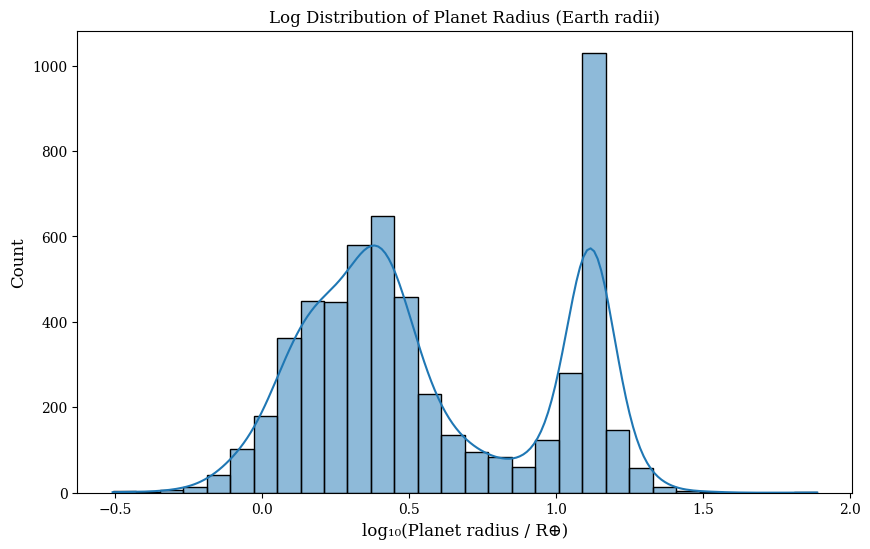

In [71]:
params = ["pl_rade", "pl_bmasse", "pl_orbper", "st_teff", "st_lum", "sy_dist"]
merged_subset = merged[params].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(10, 6))
sns.histplot(np.log10(merged_subset["pl_rade"].dropna()), bins=30, kde=True)
plt.title("Log Distribution of Planet Radius (Earth radii)")
plt.xlabel("log₁₀(Planet radius / R⊕)")
plt.show();

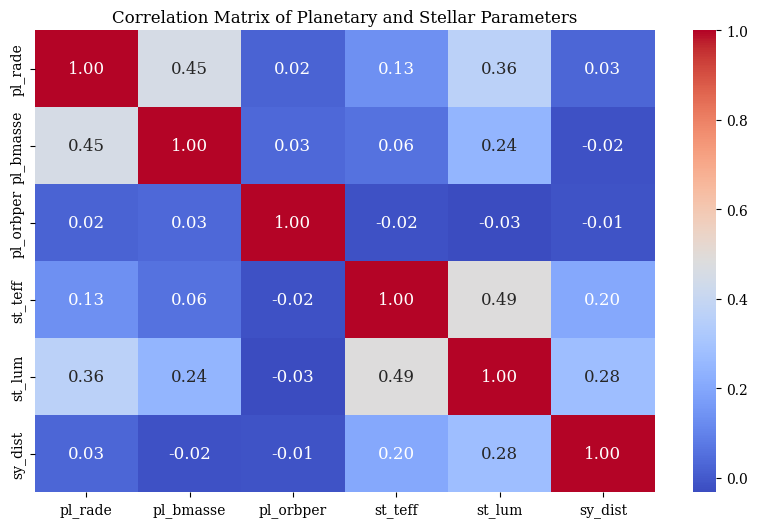

In [72]:
corr = merged_subset.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Planetary and Stellar Parameters")
plt.show();

P_HABITABLE
0    5506
2      41
1      29
Name: count, dtype: int64
P_HABITABLE
0    5506
1      70
Name: count, dtype: int64


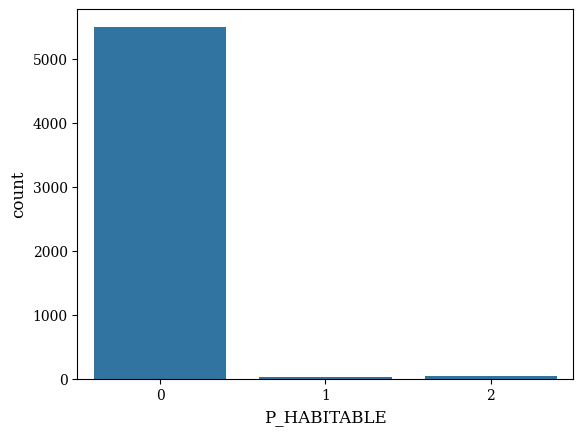

In [74]:
if "P_HABITABLE" in merged.columns:
    print(merged["P_HABITABLE"].value_counts(dropna=False))
    sns.countplot(x="P_HABITABLE", data=merged)

# Load your merged dataset
data = pd.read_csv("../data/selected_columns.csv")

# Define mapping: habitable + potentially habitable → 1, others → 0
data["P_HABITABLE"] = data["P_HABITABLE"].apply(
    lambda x: 1 if x in [1,2] else 0
)

print(data["P_HABITABLE"].value_counts(dropna=False))

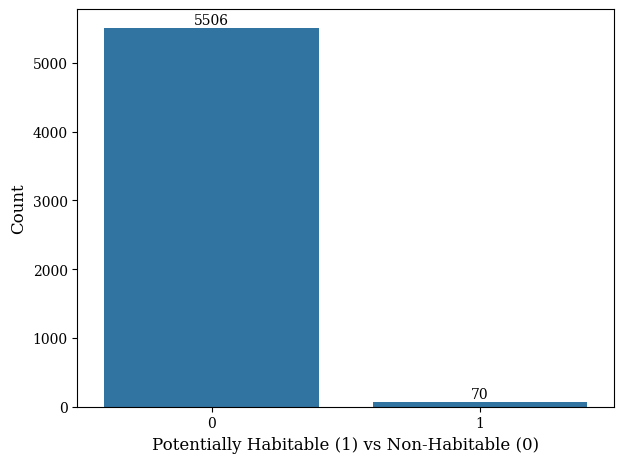

In [ ]:
ax = sns.countplot(x="P_HABITABLE", data=data)

ax.set_xlabel("Potentially Habitable (1) vs Non-Habitable (0)")
ax.set_ylabel("Count")

for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f"{int(height)}",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 1),          # vertical offset
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig(
    "p_habitable_count.pdf",
    dpi=300,
    format="pdf")

In [76]:
# Optionally, limit to physically relevant continuous features
features = [f for f in data.columns if f!='P_HABITABLE']

X = data[features]

In [77]:
features

['pl_orbper',
 'pl_orbsmax',
 'pl_orbeccen',
 'pl_rade',
 'pl_bmasse',
 'pl_dens',
 'pl_insol',
 'pl_eqt',
 'P_RADIUS',
 'P_MASS',
 'P_DENSITY',
 'P_FLUX',
 'P_TEMP_EQUIL',
 'st_teff',
 'st_rad',
 'st_lum',
 'st_mass',
 'S_RADIUS',
 'S_LUMINOSITY',
 'S_MASS',
 'sy_dist',
 'sy_pnum',
 'P_ESI']

In [78]:
corr = X.corr().round(2)

In [81]:
# Boolean missing indicator matrix
col_labels = [c for c in data.columns if c != "P_HABITABLE"]
missing = data[col_labels].isna()

rows = []

for idx in missing.index:
    # extract which features are missing
    tup = tuple(missing.columns[missing.loc[idx]].tolist())
    rows.append(tup)

# Count occurrences of each tuple
result = pd.Series(rows).value_counts().reset_index()

result.columns = ["missing_features", "count"]
result["n_missing"] = result["missing_features"].apply(len)

result.head()

,missing_features,count,n_missing
0,(),3599,0
1,"(pl_insol, pl_eqt)",904,2
2,"(pl_orbper, pl_orbeccen, pl_insol, pl_eqt, P_F...",189,12
3,"(pl_insol,)",134,1
4,"(pl_orbsmax, pl_orbeccen, pl_insol, pl_eqt)",128,4


In [82]:
result_noempty = result[result["n_missing"] > 0].copy()

memberships = []

for feats, cnt in zip(result_noempty["missing_features"], result_noempty["count"]):
    memberships.extend([list(feats)] * cnt)

print("Sample:", memberships[:10])

Sample: [['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt'], ['pl_insol', 'pl_eqt']]


In [83]:
import warnings
from upsetplot import from_memberships

# --- Suppress known pandas+upsetplot warnings ---
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

upset_data = from_memberships(memberships)
upset_data.head()

P_DENSITY  P_ESI  P_FLUX  P_MASS  P_RADIUS  P_TEMP_EQUIL  S_LUMINOSITY  S_MASS  S_RADIUS  pl_bmasse  pl_dens  pl_eqt  pl_insol  pl_orbeccen  pl_orbper  pl_orbsmax  pl_rade  st_lum  st_mass  st_rad  st_teff  sy_dist
False      False  False   False   False     False         False         False   False     False      False    True    True      False        False      False       False    False   False    False   False    False      1
                                                                                                                                                                                                               False      1
                                                                                                                                                                                                               False      1
                                                                                                                             

<Figure size 1200x800 with 0 Axes>

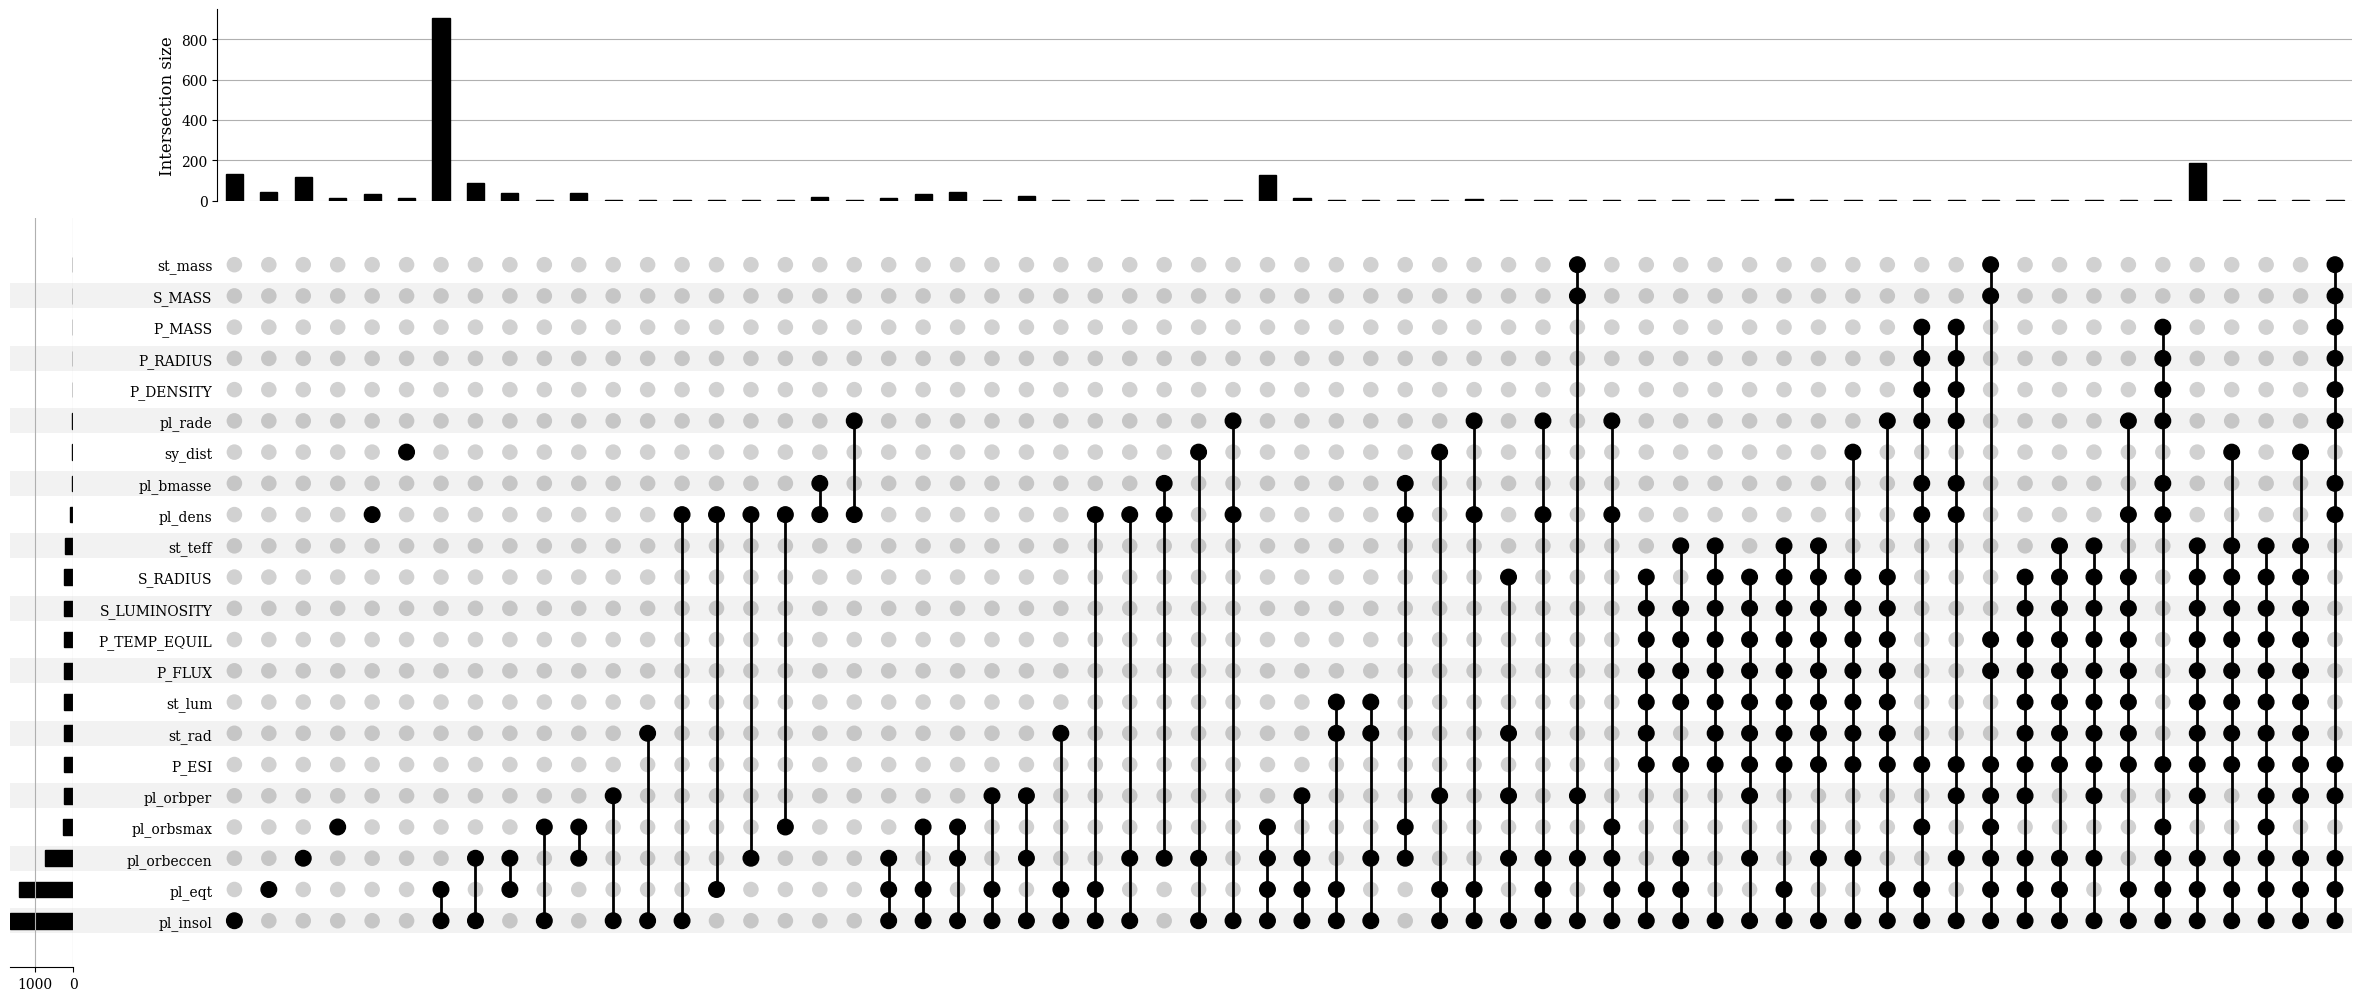

In [84]:
from upsetplot import UpSet

plt.figure(figsize=(12, 8))
UpSet(upset_data, subset_size='count', sort_by='degree').plot()
plt.show();

In [85]:
# 1) Exact duplicates
dupe_cols = {}
for col in data.columns:
    for col2 in data.columns:
        if col < col2:
            if data[col].equals(data[col2]):
                dupe_cols.setdefault(col, []).append(col2)

# 2) High correlation; flag candidates with |corr| > 0.995
corr = data.corr(numeric_only=True)
high_corr_pairs = [
    (i, j, corr.loc[i, j])
    for i in corr.columns
    for j in corr.columns
    if i < j and abs(corr.loc[i, j]) > 0.995
]
high_corr_pairs

[('pl_orbper', 'pl_orbsmax', np.float64(0.9967560268443539)),
 ('P_RADIUS', 'pl_rade', np.float64(0.9994733166328847)),
 ('S_RADIUS', 'st_rad', np.float64(0.9967279617992004)),
 ('S_MASS', 'st_mass', np.float64(0.9966566823994403))]

In [86]:
X = data.select_dtypes('number').dropna()
rank = np.linalg.matrix_rank(X.values)
p = X.shape[1]
print("Rank deficiency:", p - rank)

Rank deficiency: 0


In [87]:
from sklearn.linear_model import LinearRegression

y = data['pl_eqt']
X = data[['pl_insol']].dropna()
common = X.index.intersection(y.dropna().index)

reg = LinearRegression().fit(X.loc[common], y.loc[common])
print("R²:", reg.score(X.loc[common], y.loc[common]))

R²: 0.34320386562346605


In [88]:
hab = data[data['P_HABITABLE'] == 1].copy()
print("Number of habitable planets:", hab.shape[0])

Number of habitable planets: 70


In [89]:
hab_missing_rates = hab.isna().mean().sort_values(ascending=False)
hab_missing_rates

pl_eqt          0.271429
pl_insol        0.228571
pl_orbeccen     0.142857
pl_dens         0.042857
st_rad          0.042857
pl_orbsmax      0.028571
pl_rade         0.000000
pl_orbper       0.000000
pl_bmasse       0.000000
P_RADIUS        0.000000
P_DENSITY       0.000000
P_MASS          0.000000
P_FLUX          0.000000
P_TEMP_EQUIL    0.000000
st_teff         0.000000
st_lum          0.000000
st_mass         0.000000
S_RADIUS        0.000000
S_LUMINOSITY    0.000000
S_MASS          0.000000
sy_dist         0.000000
sy_pnum         0.000000
P_HABITABLE     0.000000
P_ESI           0.000000
dtype: float64

In [90]:
hab_missing_any = hab_missing_rates[hab_missing_rates > 0]
hab_missing_any

pl_eqt         0.271429
pl_insol       0.228571
pl_orbeccen    0.142857
pl_dens        0.042857
st_rad         0.042857
pl_orbsmax     0.028571
dtype: float64

In [91]:
missing_counts = hab.isna().sum()
missing_counts[missing_counts > 0]

pl_orbsmax      2
pl_orbeccen    10
pl_dens         3
pl_insol       16
pl_eqt         19
st_rad          3
dtype: int64

In [92]:
complete_habitable_rows = (hab.isna().sum(axis=1) == 0).sum()
complete_habitable_rows

np.int64(38)

In [93]:
redundant_pairs = [
    ("pl_rade", "P_RADIUS"),
    ("pl_bmasse", "P_MASS"),
    ("pl_dens", "P_DENSITY"),
    ("pl_insol", "P_FLUX"),
    ("pl_eqt", "P_TEMP_EQUIL"),
    ("st_rad", "S_RADIUS"),
    ("st_lum", "S_LUMINOSITY"),
    ("st_mass", "S_MASS")
]

In [94]:
cleaned_df = data.copy()   # create a working copy

for A, B in redundant_pairs:
    print("="*70)
    print(f"Evaluating redundancy pair: ({A}, {B})")
    print("="*70)

    # -----------------------------------------------------
    # (1) Missingness statistics
    # -----------------------------------------------------
    miss_A = cleaned_df[A].isna().sum()
    miss_B = cleaned_df[B].isna().sum()
    miss_both = cleaned_df[[A, B]].isna().all(axis=1).sum()
    fillable = cleaned_df[A].isna() & cleaned_df[B].notna()

    print(f"Missing in {A}: {miss_A}")
    print(f"Missing in {B}: {miss_B}")
    print(f"Missing in both: {miss_both}")
    print(f"Values in {B} that can fill {A}: {fillable.sum()}")

    # -----------------------------------------------------
    # (2) Correlation analysis (only for overlapping non-NaN)
    # -----------------------------------------------------
    valid = cleaned_df[[A, B]].dropna()
    if len(valid) > 0:
        pearson = valid[A].corr(valid[B], method="pearson")
        spearman = valid[A].corr(valid[B], method="spearman")
        rel_diff = np.median(np.abs(valid[A] - valid[B]) / (np.abs(valid[A]) + 1e-12))

        print(f"Pearson correlation:  {pearson:.5f}")
        print(f"Spearman correlation: {spearman:.5f}")
        print(f"Median relative difference: {rel_diff:.5f}")

    else:
        print("Insufficient overlapping data for correlation tests.")

    # -----------------------------------------------------
    # (3) Selection of which variable to keep
    # -----------------------------------------------------
    # Rule: keep the one with fewer missing values
    if miss_A <= miss_B:
        primary, secondary = A, B
    else:
        primary, secondary = B, A

    print(f"Selected primary feature: {primary}")
    print(f"Secondary feature (will be used only to fill NA then removed): {secondary}")

    # -----------------------------------------------------
    # (4) Fill primary missing values using the secondary
    # -----------------------------------------------------
    cleaned_df[primary] = cleaned_df[primary].fillna(cleaned_df[secondary])

    # -----------------------------------------------------
    # (5) Remove the redundant feature
    # -----------------------------------------------------
    cleaned_df = cleaned_df.drop(columns=[secondary])
    print(f"Dropped redundant column: {secondary}\n")


Evaluating redundancy pair: (pl_rade, P_RADIUS)
Missing in pl_rade: 21
Missing in P_RADIUS: 7
Missing in both: 7
Values in P_RADIUS that can fill pl_rade: 14
Pearson correlation:  0.99947
Spearman correlation: 0.99890
Median relative difference: 0.00000
Selected primary feature: P_RADIUS
Secondary feature (will be used only to fill NA then removed): pl_rade
Dropped redundant column: pl_rade

Evaluating redundancy pair: (pl_bmasse, P_MASS)
Missing in pl_bmasse: 30
Missing in P_MASS: 7
Missing in both: 7
Values in P_MASS that can fill pl_bmasse: 23
Pearson correlation:  0.92800
Spearman correlation: 0.98259
Median relative difference: 0.00000
Selected primary feature: P_MASS
Secondary feature (will be used only to fill NA then removed): pl_bmasse
Dropped redundant column: pl_bmasse

Evaluating redundancy pair: (pl_dens, P_DENSITY)
Missing in pl_dens: 94
Missing in P_DENSITY: 7
Missing in both: 7
Values in P_DENSITY that can fill pl_dens: 87
Pearson correlation:  0.47636
Spearman correlat

In [95]:
cleaned_df.to_csv("../data/cleaned_selected_columns.csv", index=False)

In [96]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5576 entries, 0 to 5575
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pl_orbper     5329 non-null   float64
 1   pl_orbsmax    5313 non-null   float64
 2   pl_orbeccen   4840 non-null   float64
 3   P_RADIUS      5569 non-null   float64
 4   P_MASS        5569 non-null   float64
 5   P_DENSITY     5569 non-null   float64
 6   P_FLUX        5343 non-null   float64
 7   P_TEMP_EQUIL  5352 non-null   float64
 8   st_teff       5358 non-null   float64
 9   st_mass       5572 non-null   float64
 10  S_RADIUS      5345 non-null   float64
 11  S_LUMINOSITY  5344 non-null   float64
 12  sy_dist       5555 non-null   float64
 13  sy_pnum       5576 non-null   int64  
 14  P_HABITABLE   5576 non-null   int64  
 15  P_ESI         5336 non-null   float64
dtypes: float64(14), int64(2)
memory usage: 697.1 KB


In [97]:
cleaned_df.columns

Index(['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'P_RADIUS', 'P_MASS',
       'P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL', 'st_teff', 'st_mass', 'S_RADIUS',
       'S_LUMINOSITY', 'sy_dist', 'sy_pnum', 'P_HABITABLE', 'P_ESI'],
      dtype='object')

In [98]:
hab = cleaned_df[cleaned_df['P_HABITABLE'] == 1].copy()
print("Number of habitable planets:", hab.shape[0])

Number of habitable planets: 70


In [99]:
missing_counts = hab.isna().sum()
missing_counts[missing_counts > 0]

pl_orbsmax      2
pl_orbeccen    10
dtype: int64

In [100]:
complete_habitable_rows = (hab.isna().sum(axis=1) == 0).sum()
complete_habitable_rows

np.int64(59)

In [101]:
# Boolean missing indicator matrix
col_labels = [c for c in cleaned_df.columns if c != "P_HABITABLE"]
missing = cleaned_df[col_labels].isna()

rows = []

for idx in missing.index:
    # extract which features are missing
    tup = tuple(missing.columns[missing.loc[idx]].tolist())
    rows.append(tup)

# Count occurrences of each tuple
result = pd.Series(rows).value_counts().reset_index()

result.columns = ["missing_features", "count"]
result["n_missing"] = result["missing_features"].apply(len)

result.head()

,missing_features,count,n_missing
0,(),4758,0
1,"(pl_orbeccen,)",268,1
2,"(pl_orbsmax, pl_orbeccen)",210,2
3,"(pl_orbper, pl_orbeccen, P_FLUX, P_TEMP_EQUIL,...",189,8
4,"(pl_orbsmax,)",45,1


In [102]:
result_noempty = result[result["n_missing"] > 0].copy()

memberships = []

for feats, cnt in zip(result_noempty["missing_features"], result_noempty["count"]):
    memberships.extend([list(feats)] * cnt)

In [103]:
import warnings
from upsetplot import from_memberships

# --- Suppress known pandas+upsetplot warnings ---
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

upset_data = from_memberships(memberships)
upset_data.head()

P_DENSITY  P_ESI  P_FLUX  P_MASS  P_RADIUS  P_TEMP_EQUIL  S_LUMINOSITY  S_RADIUS  pl_orbeccen  pl_orbper  pl_orbsmax  st_mass  st_teff  sy_dist
False      False  False   False   False     False         False         False     True         False      False       False    False    False      1
                                                                                                                                        False      1
                                                                                                                                        False      1
                                                                                                                                        False      1
                                                                                                                                        False      1
Name: ones, dtype: int64

In [104]:
label_map = {
    "pl_orbper": "Orbital period",
    "pl_orbsmax": "Semi-major axis",
    "pl_orbeccen": "Eccentricity",
    "P_RADIUS": "Planet radius",
    "P_MASS": "Planet mass",
    "P_DENSITY": "Planet density",
    "P_FLUX": "Incident flux",
    "P_TEMP_EQUIL": "Equilibrium temp.",
    "st_teff": "Stellar $T_{\\mathrm{eff}}$",
    "st_mass": "Stellar mass",
    "S_RADIUS": "Stellar radius",
    "S_LUMINOSITY": "Stellar luminosity",
    "sy_dist": "System distance",
    "sy_pnum": "Planets in system",
    "P_HABITABLE": "Habitability label",
    "P_ESI": "Earth Similarity Index"
}

In [106]:
FEATURE_LABELS = {
    "pl_orbper": "Orbital period",
    "pl_orbsmax": "Semi-major axis",
    "pl_orbeccen": "Eccentricity",
    "P_RADIUS": "Planet radius",
    "P_MASS": "Planet mass",
    "P_DENSITY": "Planet density",
    "P_FLUX": "Incident flux",
    "P_TEMP_EQUIL": "Equilibrium temp.",
    "st_teff": "Stellar $T_{\\rm eff}$",
    "st_mass": "Stellar mass",
    "S_RADIUS": "Stellar radius",
    "S_LUMINOSITY": "Stellar luminosity",
    "sy_dist": "System distance",
    "sy_pnum": "Planets in system",
    "P_ESI": "Earth Similarity Index"
}

In [107]:
upset_data_renamed = upset_data.copy()
upset_data_renamed.index = upset_data.index.set_names(
    [FEATURE_LABELS.get(n, n) for n in upset_data.index.names]
)

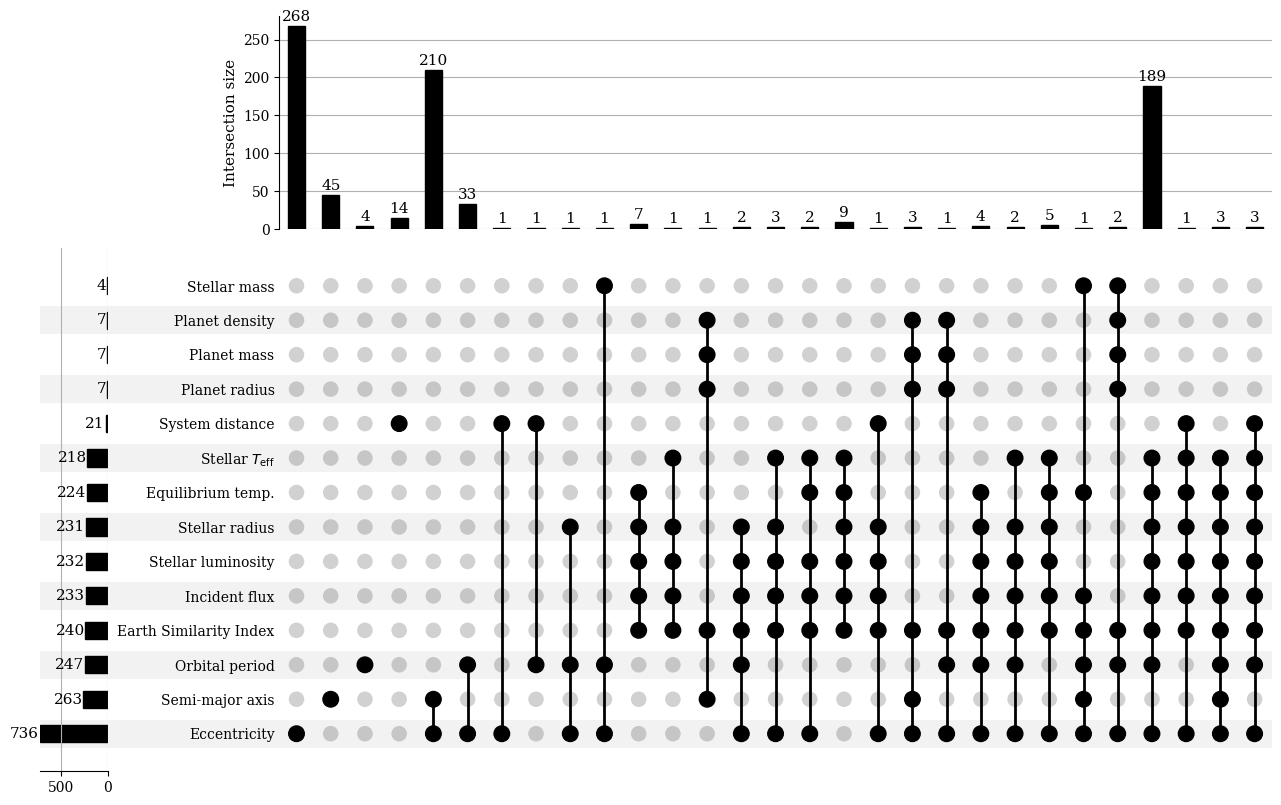

In [112]:
from upsetplot import UpSet
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig = plt.figure(figsize=(13, 8))

UpSet(
    upset_data_renamed,
    subset_size="count",
    sort_by="degree",        # complexity of missingness
    show_counts=True,
    show_percentages=False,
    facecolor="black"
).plot(fig=fig)

fig.subplots_adjust(
    left=0.18,    # room for feature labels
    right=0.95,
    top=0.95,
    bottom=0.10,
    wspace=0.02,
    hspace=0.02
)

plt.savefig("missing.pdf")
plt.show();

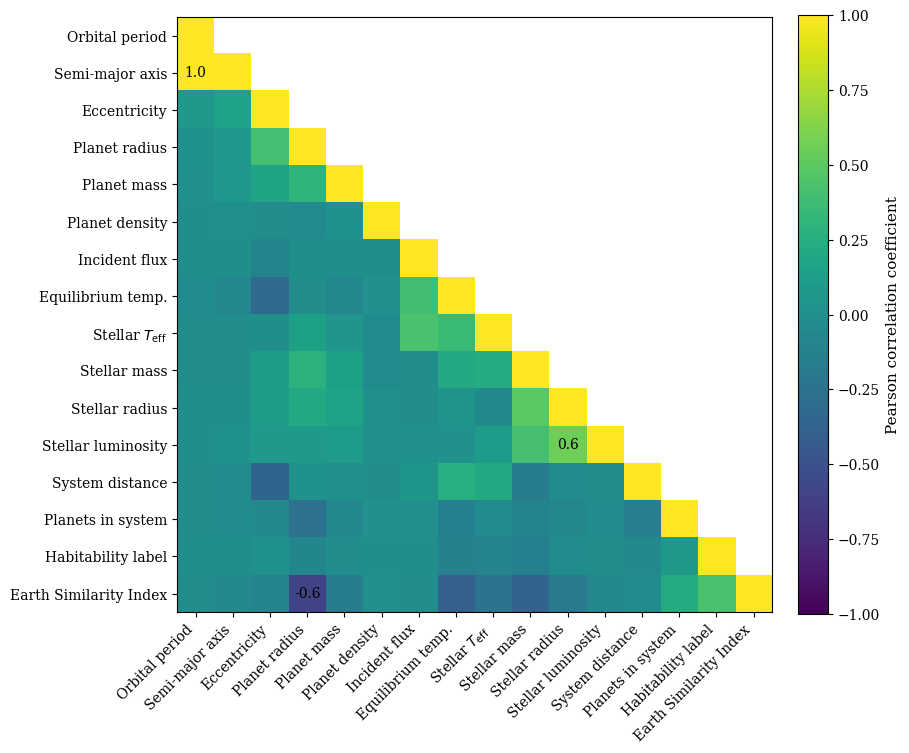

In [109]:
corr_matrix = cleaned_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 8))

corr = corr_matrix.values
cols = corr_matrix.columns

# Mask upper triangle + diagonal
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = np.ma.array(corr, mask=mask)

im = ax.imshow(corr_masked, vmin=-1, vmax=1)

# Axis ticks with descriptive labels
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))

ax.set_xticklabels([label_map[c] for c in cols],
                   rotation=45, ha="right")
ax.set_yticklabels([label_map[c] for c in cols])

# Annotate only meaningful correlations (lower triangle only)
ANNOT_THRESH = 0.5

for i in range(len(cols)):
    for j in range(i):
        val = corr[i, j]
        if abs(val) >= ANNOT_THRESH:
            ax.text(
                j, i, f"{val:.1f}",
                ha="center", va="center",
                fontsize=10,
                color="black"
            )

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation coefficient")

# ax.set_title("Correlation matrix of final feature set")

plt.tight_layout()

plt.savefig("corr.pdf")

plt.show();

In [113]:
features_to_plot = [
    "P_RADIUS",
    "P_MASS",
    "P_FLUX",
    "P_TEMP_EQUIL",
    "pl_orbeccen",
    "P_ESI"
]

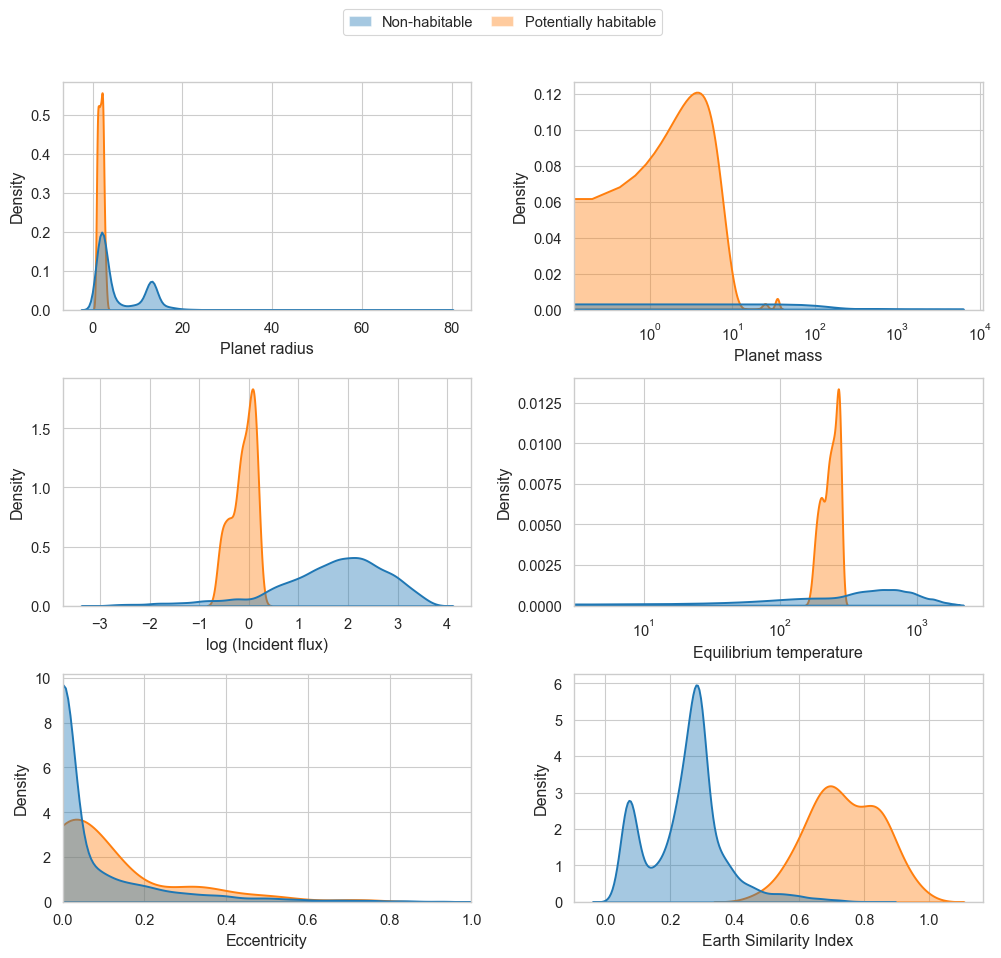

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

# -------------------------
# Style
# -------------------------
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

# -------------------------
# Feature labels
# -------------------------
FEATURE_LABELS = {
    "P_RADIUS": "Planet radius",
    "P_MASS": "Planet mass",
    "P_FLUX": "Incident flux",
    "P_TEMP_EQUIL": "Equilibrium temperature",
    "pl_orbeccen": "Eccentricity",
    "P_ESI": "Earth Similarity Index",
}

features_to_plot = list(FEATURE_LABELS.keys())

log_features = {"P_MASS", "P_TEMP_EQUIL"}
clip_features = {"P_MASS", "P_TEMP_EQUIL", "P_FLUX"}

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, col in zip(axes, features_to_plot):

    df_plot = cleaned_df[[col, "P_HABITABLE"]].dropna()

    # Physical correction
    if col == "pl_orbeccen":
        df_plot[col] = df_plot[col].clip(lower=0)

    # Quantile clipping for visualization
    if col in clip_features:
        q01, q99 = df_plot[col].quantile([0.01, 0.99])
        df_plot = df_plot[(df_plot[col] >= q01) & (df_plot[col] <= q99)]

    # Special handling for incident flux
    if col == "P_FLUX":
        df_plot = df_plot.copy()
        df_plot["log_flux"] = np.log10(df_plot[col])

        sns.kdeplot(
            data=df_plot,
            x="log_flux",
            hue="P_HABITABLE",
            hue_order=[0, 1],
            fill=True,
            alpha=0.4,
            linewidth=1.4,
            common_norm=False,
            bw_adjust=0.8,
            legend=False,
            ax=ax
        )
        ax.set_xlabel("log (Incident flux)")

    else:
        sns.kdeplot(
            data=df_plot,
            x=col,
            hue="P_HABITABLE",
            hue_order=[0, 1],
            fill=True,
            alpha=0.4,
            linewidth=1.4,
            common_norm=False,
            bw_adjust=0.7 if col in log_features else 1.0,
            legend=False,
            ax=ax
        )

        if col in log_features:
            ax.set_xscale("log")

        if col == 'pl_orbeccen':
            ax.set_xlim(0, 1)

        ax.set_xlabel(FEATURE_LABELS[col])

    ax.set_ylabel("Density")

# -------------------------
# Shared legend (explicit)
# -------------------------
legend_handles = [
    Patch(facecolor=sns.color_palette()[0], alpha=0.4, label="Non-habitable"),
    Patch(facecolor=sns.color_palette()[1], alpha=0.4, label="Potentially habitable"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),  # move legend closer to plots
    ncol=2,
    frameon=True,
    handlelength=1.5,
    columnspacing=1.2
)

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.9,
    bottom=0.08,
    wspace=0.25,
    hspace=0.3
)

plt.savefig(
    "features.pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show();